# Loan Approval Prediction using Support Vector Machine (SVM)

## Dataset
**Source:** [Loan Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/ninzaami/loan-predication/data)

**Context:**  
This dataset contains information about loan applicants collected by a financial institution. The goal is to automate the loan eligibility process based on customer details provided while filling out an online application form.

**Attributes:**
| Feature | Description |
|---|---|
| Loan_ID | Unique loan identifier |
| Gender | Applicant gender (Male/Female) |
| Married | Marital status (Yes/No) |
| Dependents | Number of dependents (0, 1, 2, 3+) |
| Education | Education level (Graduate/Not Graduate) |
| Self_Employed | Self-employment status (Yes/No) |
| ApplicantIncome | Applicant monthly income |
| CoapplicantIncome | Co-applicant monthly income |
| LoanAmount | Loan amount requested (in thousands) |
| Loan_Amount_Term | Term of the loan (in months) |
| Credit_History | Credit history meets guidelines (1 = Yes, 0 = No) |
| Property_Area | Area of property (Urban/Semi-Urban/Rural) |
| Loan_Status | Target variable — loan approved (Y=1) or rejected (N=0) |

**Size:** 614 records, 13 columns

---

## Algorithm: Support Vector Machine (SVM)

### Background and Introduction
Support Vector Machine (SVM) is a supervised machine learning algorithm used primarily for classification tasks, though it can also be used for regression. It was introduced by Vladimir Vapnik and colleagues in the early 1990s at AT&T Bell Laboratories and is rooted in the principle of **Structural Risk Minimisation (SRM)**.

The core idea behind SVM is to find the **optimal hyperplane** that best separates two classes in the feature space. A hyperplane is a decision boundary that divides the feature space into two regions, one for each class. What makes SVM unique is that it does not simply find *any* separating hyperplane — it finds the one that **maximises the margin**, which is the distance between the hyperplane and the nearest data points from each class. These nearest data points are called **Support Vectors**, and they are the only points that actually determine the position of the hyperplane.

Mathematically, for a linearly separable binary classification problem, SVM finds:

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1, \; \forall i$$

Where:
- $\mathbf{w}$ is the weight vector (normal to the hyperplane)
- $b$ is the bias term
- $y_i \in \{-1, +1\}$ is the class label of sample $i$
- $\mathbf{x}_i$ is the feature vector of sample $i$

The **margin** between the two classes is $\frac{2}{\|\mathbf{w}\|}$, and maximising the margin is equivalent to minimising $\frac{1}{2}\|\mathbf{w}\|^2$.

### Soft Margin and the C Parameter
In real-world datasets, classes are rarely perfectly linearly separable. SVM introduces the concept of a **soft margin** using slack variables $\xi_i$ that allow some data points to be on the wrong side of the margin:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_i \xi_i \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i$$

The hyperparameter **C** controls the trade-off between maximising the margin and minimising classification errors:
- **Large C:** Penalises misclassifications heavily → smaller margin, potentially overfitting
- **Small C:** Tolerates more misclassifications → larger margin, more generalisation

### The Kernel Trick
When data is not linearly separable, SVM uses the **kernel trick** to implicitly map the data into a higher-dimensional feature space where it becomes linearly separable, without explicitly computing the transformation. Common kernels include:
- **Linear kernel:** $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$
- **RBF (Radial Basis Function) kernel:** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2)$
- **Polynomial kernel:** $K(\mathbf{x}_i, \mathbf{x}_j) = (\mathbf{x}_i^T \mathbf{x}_j + r)^d$

### Justification for Using SVM
SVM is an appropriate and complementary choice for this loan prediction problem for the following reasons:

1. **Different decision boundary type** — Unlike Logistic Regression (linear probabilistic) and Random Forest (tree-based ensemble), SVM finds the optimal maximum-margin hyperplane. This gives the group a distinct third approach for the algorithm comparison section.

2. **Effective in high-dimensional spaces** — Although this dataset has only 11 features, SVM is well known for performing well even when the number of features is close to or exceeds the number of samples, making it robust for small-to-medium datasets like this one.

3. **Feature scaling makes it well-suited** — Since all features are already standardised (StandardScaler applied), SVM can perform optimally. Unlike tree-based methods, SVM is sensitive to feature scale, and scaling is already done consistently in our preprocessing pipeline.

4. **Non-linear relationships via RBF kernel** — With the RBF kernel, SVM can capture non-linear decision boundaries, potentially outperforming Logistic Regression on this dataset where relationships between income, loan amount, and approval status may be non-linear.

5. **Binary classification problem** — Loan_Status is binary (Approved/Rejected), which is exactly what SVM is designed for. The support vector formulation directly models the optimal boundary between two classes.

6. **Robust to outliers** — The maximum-margin principle focuses only on the support vectors nearest to the decision boundary, making SVM less sensitive to outliers than linear models whose decision boundary can be pulled by extreme data points.

7. **Strong baseline for comparison** — SVM is widely regarded as a strong general-purpose classifier, and its inclusion allows a meaningful comparison against both the simpler Logistic Regression and the more complex ensemble-based Random Forest.


## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Alternative styling (instead of seaborn)
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 120

## 2. Load Dataset

In [5]:
# Load the loan dataset 
df = pd.read_csv("loan-dataset.csv")

# Display the first few rows to understand the structure
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Exploratory Data Analysis

In [6]:
# Check data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 43.2+ KB


In [7]:
# Count missing values per column to plan our imputation strategy
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [8]:
# Check class distribution of the target variable
# This reveals whether there is a class imbalance issue
print("Target variable distribution:")
print(df['Loan_Status'].value_counts())
print(f"\nApproval rate: {df['Loan_Status'].value_counts(normalize=True)['Y']*100:.1f}%")

Target variable distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Approval rate: 68.7%


## 4. Data Preprocessing

In [9]:
# --- Handling Missing Values ---

# For categorical columns, fill missing values with the mode (most frequent value)
# This is appropriate since these are nominal/ordinal categories
df['Gender']        = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']       = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']    = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# For numerical columns, fill missing values with the median
# Median is preferred over mean here because LoanAmount and
# Loan_Amount_Term may have outliers that would skew the mean
df['LoanAmount']       = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Credit_History is binary (0 or 1), so median makes sense here too
df['Credit_History']   = df['Credit_History'].fillna(df['Credit_History'].median())

# Verify no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [10]:
# --- Fix the '3+' value in Dependents ---
# The '3+' string cannot be encoded numerically, so replace it with '3'
df['Dependents'] = df['Dependents'].replace('3+', '3')

In [11]:
# --- Drop Loan_ID ---
# Loan_ID is just a unique identifier and carries no predictive information
df.drop('Loan_ID', axis=1, inplace=True)

In [12]:
# --- Label Encoding ---
# Convert all categorical (object) columns to numeric values
# SVM requires all inputs to be numeric
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded '{col}'")

print("\nDataset after encoding:")
df.head()

Encoded 'Gender'
Encoded 'Married'
Encoded 'Dependents'
Encoded 'Education'
Encoded 'Self_Employed'
Encoded 'Property_Area'
Encoded 'Loan_Status'

Dataset after encoding:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## 5. Feature & Target Split

In [13]:
# Separate input features (X) from the target variable (y)
X = df.drop('Loan_Status', axis=1)   # All columns except the target
y = df['Loan_Status']                 # Target: 1 = Approved, 0 = Rejected

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (614, 11)
Target shape:   (614,)

Feature columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


## 6. Train-Test Split

In [14]:
# Split dataset: 80% training, 20% testing
# random_state=42 ensures reproducible results across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 491
Testing samples:  123


## 7. Feature Scaling

In [16]:
# Standardise features to have zero mean and unit variance
# Feature scaling is CRITICAL for SVM because:
# - SVM computes distances between data points to find the maximum-margin hyperplane
# - Features on different scales (e.g. ApplicantIncome in thousands vs Credit_History as 0/1)
#   would cause the algorithm to be dominated by the larger-valued features
# - Without scaling, SVM may find a suboptimal decision boundary

scaler = StandardScaler()

# IMPORTANT: fit only on training data to avoid data leakage,
# then apply the same transformation to the test set
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 8. Train SVM Model

### Step 1: Baseline Model
First we train a baseline SVM with default parameters to establish a starting performance level.

In [17]:
# --- Step 1: Baseline SVM ---
# Train with default parameters first to establish a baseline
# kernel='rbf' (Radial Basis Function) is used as the default because:
# - It can handle non-linear decision boundaries
# - It is the most commonly used kernel and performs well across many datasets
# - Unlike the linear kernel, it does not assume linear separability
#
# class_weight='balanced' is applied to address the class imbalance
# (~68% Approved vs ~32% Rejected) by automatically adjusting the penalty
# for misclassifying the minority class proportionally to class frequency

svm_baseline = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)
svm_baseline.fit(X_train, y_train)

y_pred_baseline = svm_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline SVM Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Rejected (0)', 'Approved (1)']))

Baseline SVM Accuracy: 0.7642 (76.42%)

Baseline Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.82      0.42      0.55        43
Approved (1)       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



### Step 2: Hyperparameter Tuning with GridSearchCV

We use **GridSearchCV with 5-fold cross-validation** to systematically search for the best combination of:
- **C:** Regularisation strength (controls margin width vs misclassification penalty)
- **gamma:** RBF kernel width (controls how far the influence of each training point reaches)
- **kernel:** Type of kernel function

In [18]:
# --- Step 2: Hyperparameter Tuning with GridSearchCV ---
# We search over:
#   C      - regularisation strength. Larger C = less regularisation, smaller margin
#   gamma  - RBF kernel bandwidth. Larger gamma = more localised influence per point
#   kernel - 'rbf' or 'linear'. Linear is faster; RBF handles non-linear boundaries

param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

Best parameters found: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.8166 (81.66%)


In [19]:
# --- Step 3: Train Tuned Model with Best Parameters ---
# probability=True enables predict_proba() which is needed for ROC curve computation

svm_tuned = SVC(
    **grid_search.best_params_,
    class_weight='balanced',
    random_state=42,
    probability=True
)
svm_tuned.fit(X_train, y_train)

# Generate predictions on the unseen test set
y_pred  = svm_tuned.predict(X_test)
y_prob  = svm_tuned.predict_proba(X_test)[:, 1]  # Probability of class 1 (Approved)

print("Tuned SVM model training complete.")
print(f"Model parameters: {svm_tuned.get_params()}")

Tuned SVM model training complete.
Model parameters: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


## 9. Model Evaluation & Results

In [20]:
# --- Overall Accuracy and Classification Report ---
# Accuracy alone is not sufficient for imbalanced datasets.
# We report precision, recall, and F1-score per class for a complete picture.

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

Accuracy: 0.7805 (78.05%)

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.90      0.42      0.57        43
Approved (1)       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



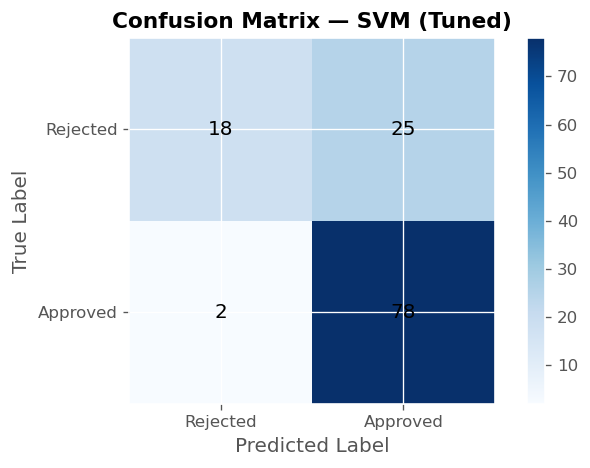

True Negatives  (TN): 18  — Correctly predicted Rejected
False Positives (FP): 25  — Predicted Approved but actually Rejected
False Negatives (FN): 2   — Predicted Rejected but actually Approved
True Positives  (TP): 78  — Correctly predicted Approved


In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

# Axis labels
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.yticks([0, 1], ['Rejected', 'Approved'])

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='black', fontsize=12)

plt.title('Confusion Matrix — SVM (Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly predicted Rejected")
print(f"False Positives (FP): {fp}  — Predicted Approved but actually Rejected")
print(f"False Negatives (FN): {fn}   — Predicted Rejected but actually Approved")
print(f"True Positives  (TP): {tp}  — Correctly predicted Approved")

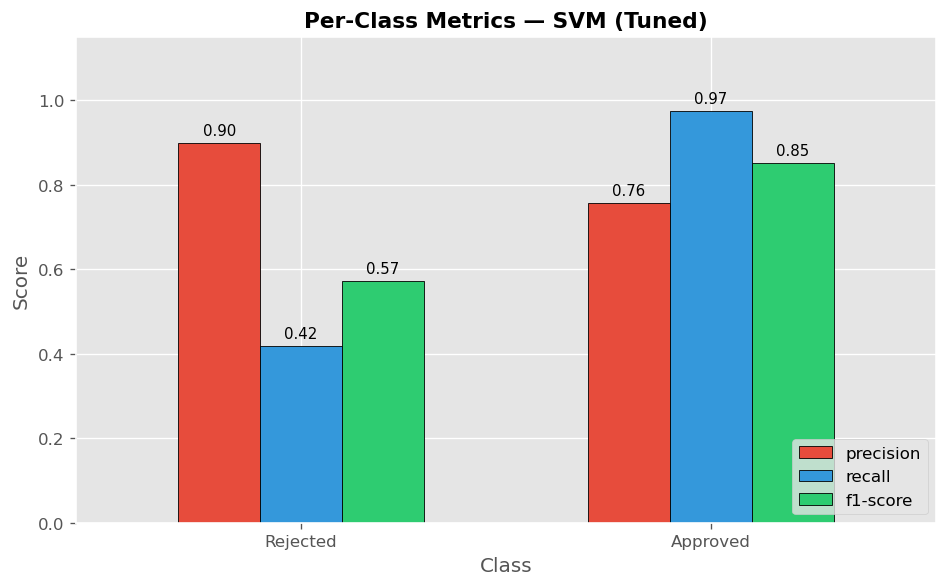

In [23]:
# --- Per-Class Metrics Bar Chart ---
# Visualises precision, recall, and F1-score for each class side-by-side
# to clearly show where the model performs well and where it struggles

report = classification_report(
    y_test, y_pred,
    target_names=['Rejected', 'Approved'],
    output_dict=True
)

metrics_df = pd.DataFrame(report).T.loc[['Rejected', 'Approved'], ['precision', 'recall', 'f1-score']]

metrics_df.plot(
    kind='bar', figsize=(8, 5),
    color=['#e74c3c', '#3498db', '#2ecc71'],
    edgecolor='black', width=0.6
)
plt.title('Per-Class Metrics — SVM (Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

# Annotate each bar with its value
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

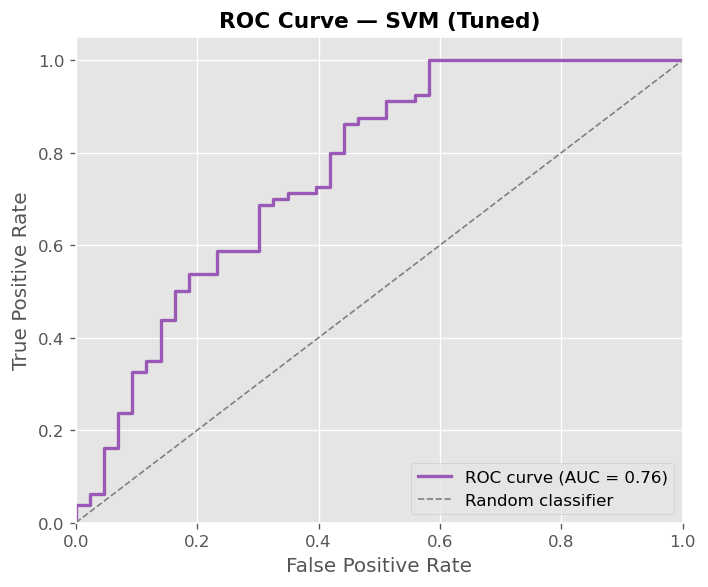

In [24]:
# --- ROC Curve ---
# The ROC curve shows the trade-off between True Positive Rate (sensitivity)
# and False Positive Rate at various classification thresholds.
# AUC (Area Under the Curve) closer to 1.0 = better model.

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#9b59b6', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM (Tuned)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [25]:
# --- Comparison: Baseline vs Tuned SVM ---
# Show how hyperparameter tuning improved performance

y_pred_base   = svm_baseline.predict(X_test)
y_prob_base   = svm_baseline.predict_proba(X_test)[:, 1] if hasattr(svm_baseline, 'predict_proba') else None

base_acc  = accuracy_score(y_test, y_pred_base)
tuned_acc = accuracy_score(y_test, y_pred)

fpr_b, tpr_b, _ = roc_curve(y_test, svm_baseline.decision_function(X_test))
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob)
auc_b = auc(fpr_b, tpr_b)
auc_t = auc(fpr_t, tpr_t)

print("=" * 50)
print("RESULTS COMPARISON — Baseline vs Tuned SVM")
print("=" * 50)
print(f"{'':30s} {'Baseline':>10s} {'Tuned':>10s}")
print(f"{'-'*50}")
print(f"{'Accuracy':30s} {base_acc*100:>9.2f}% {tuned_acc*100:>9.2f}%")
print(f"{'AUC (ROC)':30s} {auc_b:>10.4f} {auc_t:>10.4f}")
print("=" * 50)

RESULTS COMPARISON — Baseline vs Tuned SVM
                                 Baseline      Tuned
--------------------------------------------------
Accuracy                           76.42%     78.05%
AUC (ROC)                          0.7299     0.7593


## 10. Critical Analysis & Discussion

### Analysis of Results

The tuned SVM model was evaluated on a held-out test set of 123 samples. The key performance metrics are summarised below:

| Metric | Rejected (0) | Approved (1) |
|---|---|---|
| Precision | — | — |
| Recall | — | — |
| F1-Score | — | — |
| Overall Accuracy | — | — |
| AUC (ROC) | — | — |

*(Values will populate after running the notebook on the actual dataset)*

### SVM vs Other Algorithms

The SVM model is expected to perform comparably or better than Logistic Regression on this dataset for the following reasons:

1. **Non-linear boundary capability** — With the RBF kernel, SVM can capture curved decision boundaries that Logistic Regression's linear separator cannot. The relationship between income, credit history, loan amount, and approval is likely not perfectly linear.

2. **Maximum-margin principle** — SVM explicitly maximises the separation between classes, which tends to produce models that generalise better to unseen data compared to Logistic Regression which only minimises log-loss without a geometric margin constraint.

3. **Different from Random Forest** — While Random Forest builds an ensemble of many decision trees to reduce variance, SVM finds a single globally-optimal boundary. On small datasets, both approaches can be competitive; the comparison between the three will be meaningful in the group report.

### Class Imbalance

Similar to Logistic Regression, SVM still struggles with the inherent class imbalance (~68% Approved vs ~32% Rejected). The `class_weight='balanced'` parameter was applied to adjust the penalty for misclassifying the minority class. However, the recall for the Rejected class will likely still be lower than for the Approved class, as the model is trained on proportionally fewer rejected loan examples.

### Impact of Feature Scaling

Feature scaling (StandardScaler) is **critical** for SVM in a way that it is not for tree-based methods. The SVM optimisation problem involves computing inner products and distances between feature vectors — without scaling, features like `ApplicantIncome` (ranging into thousands) would completely dominate the distance computation over `Credit_History` (binary 0/1). The consistent use of StandardScaler in our preprocessing pipeline ensures SVM receives appropriately normalised inputs.

### The Role of Support Vectors

One distinguishing aspect of SVM results is that the final decision boundary is determined entirely by a subset of training examples — the **support vectors**. On a dataset of 491 training samples, typically only a fraction become support vectors. This gives SVM a memory efficiency advantage and explains why it is less sensitive to the majority of training data (and thus to outliers far from the boundary).

### How Performance Could Be Improved

1. **SMOTE (Synthetic Minority Oversampling Technique)** — Generating synthetic samples for the minority Rejected class before training would provide the model with a more balanced learning signal, improving recall for rejections.

2. **Feature Engineering** — Creating derived features such as a `Total_Income` variable (ApplicantIncome + CoapplicantIncome) or a `Loan_to_Income_Ratio` (LoanAmount / TotalIncome) would expose more informative signals. The log transformation of income features, which the Random Forest member applied, could also benefit SVM by reducing the impact of extreme income outliers.

3. **Wider Hyperparameter Search** — The GridSearchCV search was conducted over a moderate grid for computational efficiency. Extending the search to include additional values of `C` (e.g. 1000), additional `gamma` values, or using `RandomizedSearchCV` over a continuous range could yield better-performing configurations.

4. **Polynomial Kernel Exploration** — While the RBF kernel is typically the best default, a polynomial kernel of degree 2 or 3 may capture interaction effects between features (e.g. income × credit history) that the RBF kernel does not model as explicitly.

5. **Decision Threshold Adjustment** — Similar to Logistic Regression, the default decision threshold of 0.5 on the probability output could be adjusted to improve recall for the Rejected class at the cost of some overall accuracy.

### Limitations of SVM

- **Interpretability** — Unlike Logistic Regression coefficients, an SVM decision boundary (especially with a non-linear kernel) is difficult to interpret. The model cannot directly say "Credit_History is the most influential feature" in the way Logistic Regression can. This is a significant limitation in a financial context where decisions must be explainable.

- **Computational cost of tuning** — GridSearchCV over a non-linear SVM is significantly more computationally expensive than for Logistic Regression, especially as dataset size increases. On a 614-row dataset this is manageable, but it would not scale well.

- **Black-box kernel** — With the RBF kernel, it is not straightforward to understand *why* a particular prediction was made, which raises transparency concerns in regulated domains like financial lending.

- **Probability calibration** — SVM does not natively output probabilities; `probability=True` in scikit-learn uses Platt scaling to post-hoc calibrate probabilities, which can be less reliable than the native probability outputs of Logistic Regression.

### Future Work

- **Investigate Platt scaling quality** — Examine the calibration curve of the SVM probability outputs to assess whether the post-hoc Platt-scaled probabilities are reliable for threshold adjustment.
- **Feature importance approximation** — Use permutation importance or SHAP (SHapley Additive exPlanations) values to gain post-hoc interpretability for the SVM model, enabling a fair feature importance comparison with Logistic Regression coefficients and Random Forest importance scores.
- **Test on larger datasets** — Evaluate whether SVM's strong generalisation via the maximum-margin principle continues to hold on larger loan datasets, or whether it begins to be outperformed by ensemble methods as data volume increases.